<a href="https://www.kaggle.com/code/robiulhasanjisan/smartphone-usage-and-addiction-96-beats?scriptVersionId=310389207" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/algozee/smartphone-usage-and-addiction-analysis-dataset/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv


# Problem Statement

- Many real-world datasets contain complex patterns that are difficult to analyze using traditional statistical methods.

- The goal is to use machine learning models to analyze the data, discover patterns, and make accurate predictions.

**Why AI Adoption Matters**

- AI can handle large and complex datasets efficiently.

- It can detect hidden relationships and trends in the data.

- AI models help in making better data-driven decisions and predictions.

**Objectives of this Notebook**

- Perform data cleaning and preprocessing.

- Conduct Exploratory Data Analysis (EDA) and visualization.

- Train multiple machine learning models.

- Compare model performance to find the best one.

- Generate insights and predictions from the dataset.

#  Import Libraries

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

#  Load Dataset

In [3]:

df = pd.read_csv('/kaggle/input/datasets/algozee/smartphone-usage-and-addiction-analysis-dataset/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')


In [4]:
from IPython.display import display
import pandas as pd

def styled_box(df_part, title, cmap="viridis"):
    
    print(f" {title}")
   

    if isinstance(df_part, pd.DataFrame) or isinstance(df_part, pd.Series):
        display(df_part.style.background_gradient(cmap=cmap))
    else:
        print(df_part)

 


styled_box(df.shape, "DATASET SHAPE")

styled_box(df.isnull().sum().to_frame("Missing Values"), "MISSING VALUES", "Reds")

styled_box(pd.DataFrame({"Duplicates": [df.duplicated().sum()]}), "DUPLICATE ROWS", "Oranges")

styled_box(df.dtypes.to_frame("Data Types"), "DATA TYPES", "Blues")

styled_box(df.describe(), "SUMMARY STATISTICS", "viridis")

 DATASET SHAPE
(7500, 16)
 MISSING VALUES


,Missing Values
transaction_id,0
user_id,0
age,0
gender,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0


 DUPLICATE ROWS


,Duplicates
0,0


 DATA TYPES


,Data Types
transaction_id,object
user_id,object
age,int64
gender,object
daily_screen_time_hours,float64
social_media_hours,float64
gaming_hours,float64
work_study_hours,float64
sleep_hours,float64
notifications_per_day,int64


 SUMMARY STATISTICS


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


#  EDA

##  Visualizations 

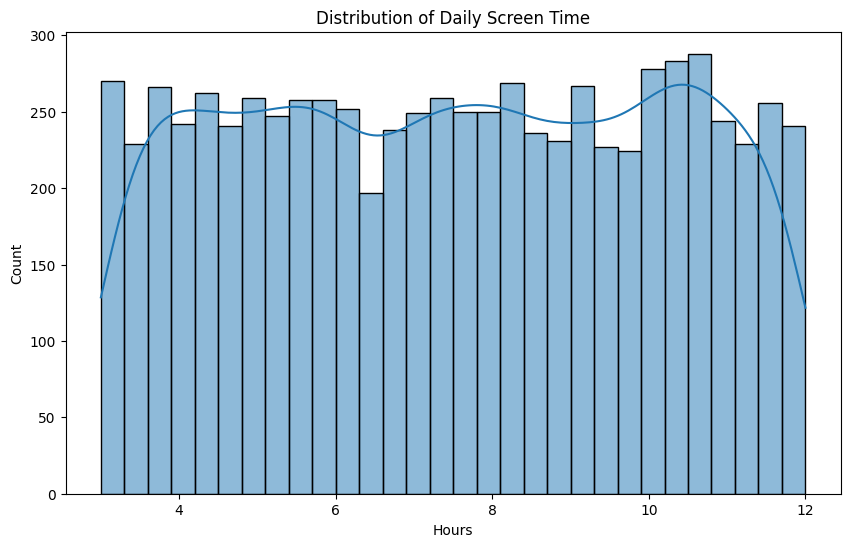

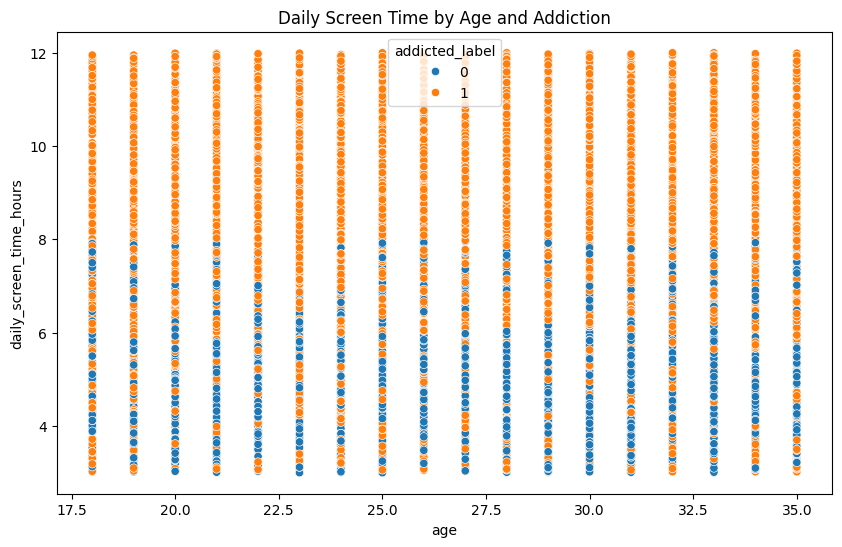

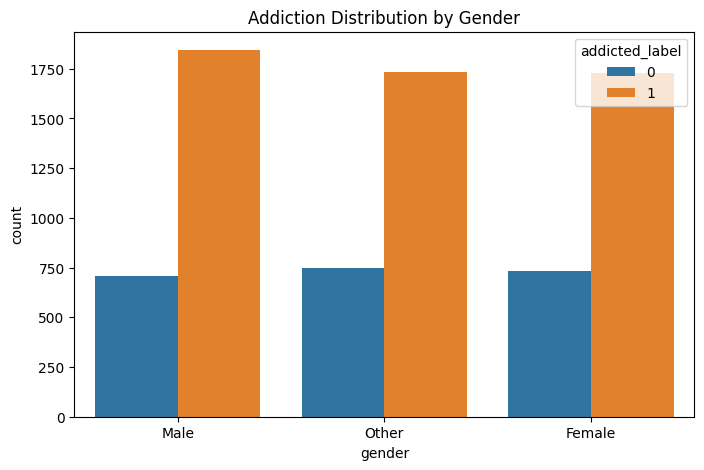

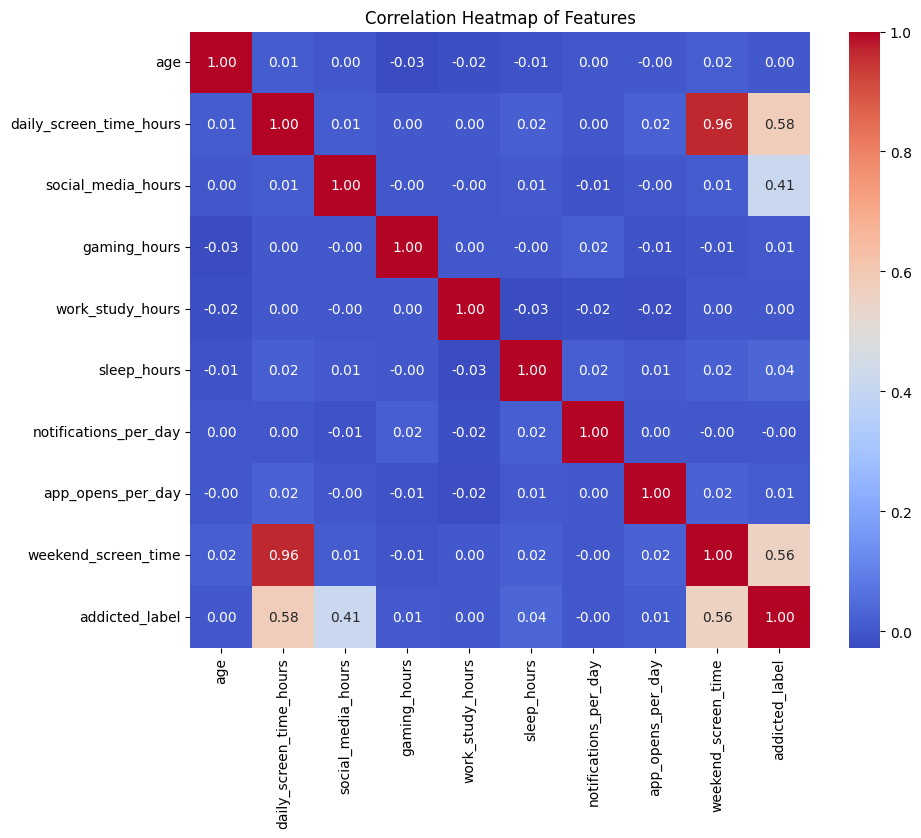

In [5]:
# Distribution of Daily Screen Time
plt.figure(figsize=(10,6))
sns.histplot(df['daily_screen_time_hours'], bins=30, kde=True)
plt.title("Distribution of Daily Screen Time")
plt.xlabel("Hours")
plt.ylabel("Count")
plt.show()


# Screen Time vs Age
plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='daily_screen_time_hours', hue='addicted_label', data=df)
plt.title("Daily Screen Time by Age and Addiction")
plt.show()


# Gender vs Addiction
plt.figure(figsize=(8,5))
sns.countplot(x='gender', hue='addicted_label', data=df)
plt.title("Addiction Distribution by Gender")
plt.show()


# Correlation Heatmap (FIXED)
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Features")
plt.show()

## MULTI-DIMENSIONAL PARALLEL COORDINATES PLOT

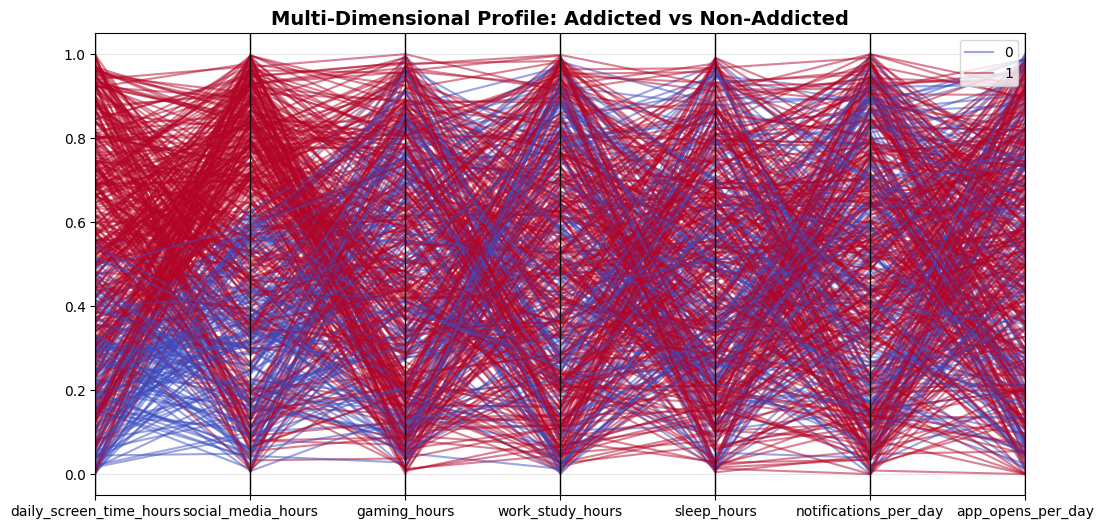

In [6]:

from pandas.plotting import parallel_coordinates

plt.figure(figsize=(12, 6))

# Normalize features for parallel coordinates
features_for_parallel = ['daily_screen_time_hours', 'social_media_hours', 
                         'gaming_hours', 'work_study_hours', 'sleep_hours',
                         'notifications_per_day', 'app_opens_per_day']
df_parallel = df[features_for_parallel + ['addicted_label']].copy()

# Normalize
for col in features_for_parallel:
    df_parallel[col] = (df_parallel[col] - df_parallel[col].min()) / (df_parallel[col].max() - df_parallel[col].min())

# Sample for better visualization
df_parallel_sample = df_parallel.sample(min(500, len(df_parallel)))
parallel_coordinates(df_parallel_sample, 'addicted_label', alpha=0.5, colormap='coolwarm')
plt.title('Multi-Dimensional Profile: Addicted vs Non-Addicted', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

## VIOLIN PLOT - Screen Time Distribution by Age Group

In [7]:
print(df.columns)

Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='object')


Columns: Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label', 'age_group'],
      dtype='object')
   age  age_group
0   21      Young
1   24  Mid-Young
2   31        Mid
3   32        Mid
4   25  Mid-Young


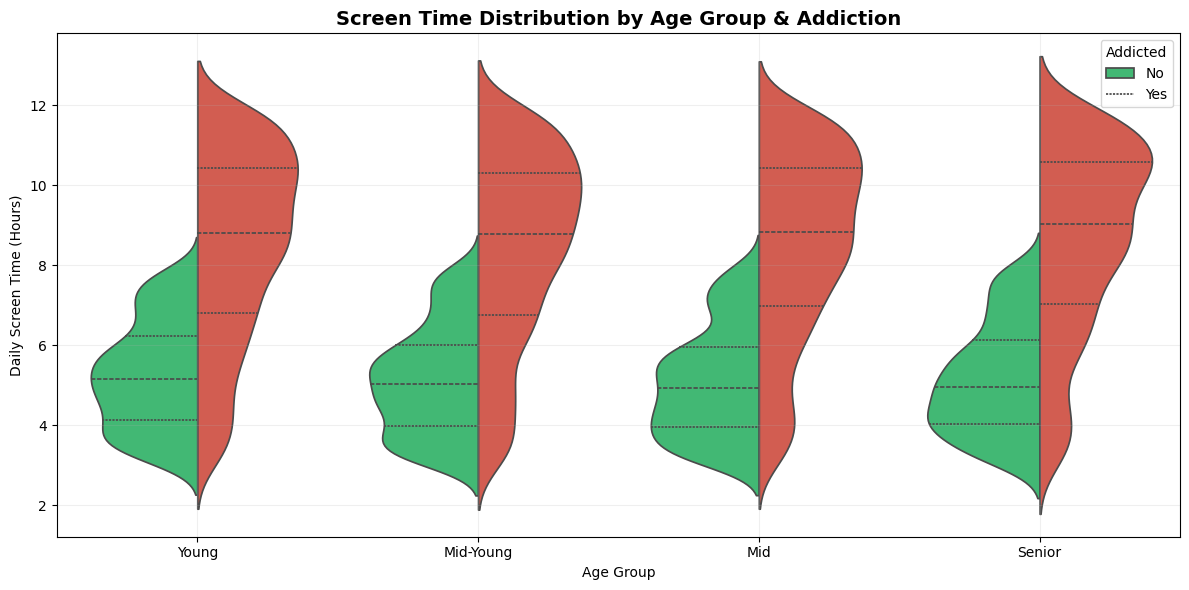

In [8]:

df['age_group'] = pd.cut(
    df['age'],
    bins=[df['age'].min(), 22, 27, 32, df['age'].max()],
    labels=['Young', 'Mid-Young', 'Mid', 'Senior'],
    include_lowest=True
)


print("Columns:", df.columns)
print(df[['age', 'age_group']].head())


plt.figure(figsize=(12, 6))

sns.violinplot(
    x='age_group',
    y='daily_screen_time_hours',
    hue='addicted_label',
    data=df,
    split=True,
    palette={0: '#2ecc71', 1: '#e74c3c'},
    inner='quartile'
)

plt.title('Screen Time Distribution by Age Group & Addiction',
          fontsize=14, fontweight='bold')

plt.xlabel('Age Group')
plt.ylabel('Daily Screen Time (Hours)')
plt.legend(title='Addicted', labels=['No', 'Yes'])

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## RADAR/SPIDER CHART - Behavioral Profile Comparison

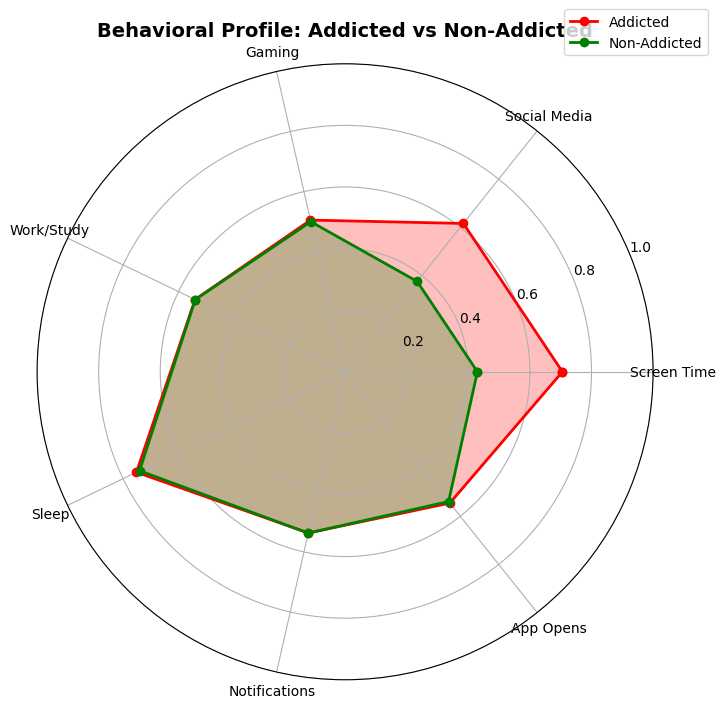

In [9]:

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='polar')

categories = ['Screen Time', 'Social Media', 'Gaming', 'Work/Study', 'Sleep', 'Notifications', 'App Opens']
metrics = ['daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 
           'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day']

# Normalize and get means
addicted_means = df[df['addicted_label'] == 1][metrics].mean()
non_addicted_means = df[df['addicted_label'] == 0][metrics].mean()

# Normalize to 0-1 scale
for metric in metrics:
    max_val = df[metric].max()
    addicted_means[metric] = addicted_means[metric] / max_val
    non_addicted_means[metric] = non_addicted_means[metric] / max_val

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
addicted_means_list = addicted_means.tolist()
non_addicted_means_list = non_addicted_means.tolist()
angles += angles[:1]
addicted_means_list += addicted_means_list[:1]
non_addicted_means_list += non_addicted_means_list[:1]

ax.plot(angles, addicted_means_list, 'o-', linewidth=2, label='Addicted', color='red')
ax.fill(angles, addicted_means_list, alpha=0.25, color='red')
ax.plot(angles, non_addicted_means_list, 'o-', linewidth=2, label='Non-Addicted', color='green')
ax.fill(angles, non_addicted_means_list, alpha=0.25, color='green')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Behavioral Profile: Addicted vs Non-Addicted', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.show()

## HEATMAP WITH HIERARCHICAL CLUSTERING

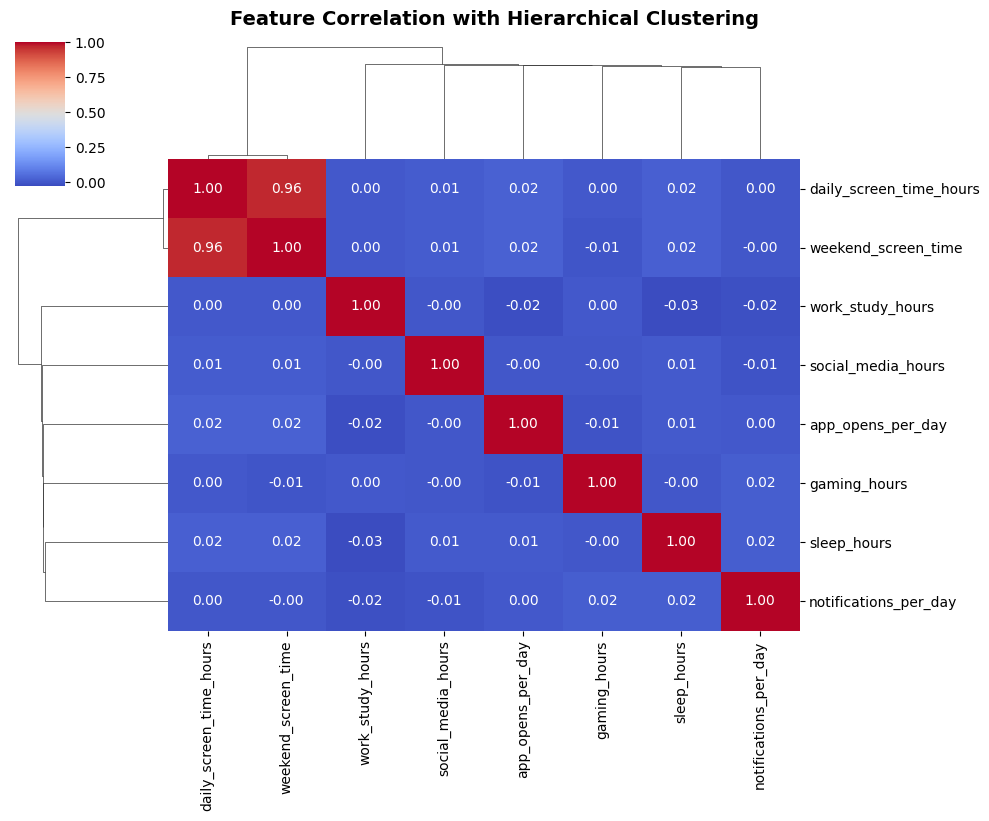

In [10]:

cluster_features = ['daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
                    'work_study_hours', 'sleep_hours', 'notifications_per_day', 
                    'app_opens_per_day', 'weekend_screen_time']

corr_matrix = df[cluster_features].corr()

# Create clustered heatmap
sns.clustermap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
               figsize=(10, 8), dendrogram_ratio=0.2)
plt.suptitle('Feature Correlation with Hierarchical Clustering', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## STACKED BAR CHART - Impact Analysis by Addiction Level

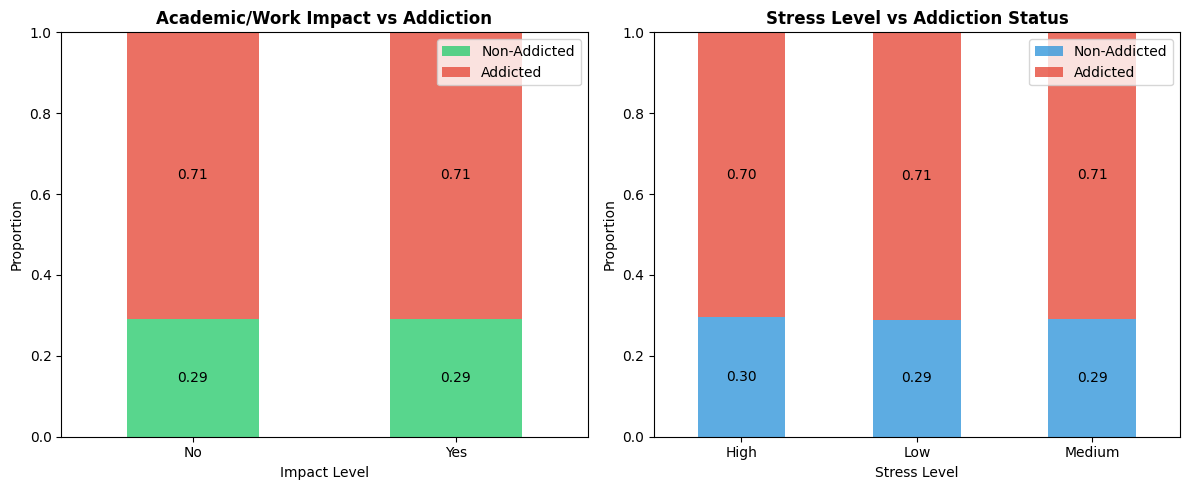

IMPACT ANALYSIS SUMMARY

Academic/Work Impact Distribution:
addicted_label               0         1
academic_work_impact                    
No                    0.292299  0.707701
Yes                   0.292234  0.707766

Stress Level Distribution:
addicted_label         0         1
stress_level                      
High            0.296484  0.703516
Low             0.288054  0.711946
Medium          0.292162  0.707838


In [11]:

plt.figure(figsize=(12, 5))

# For academic_work_impact - if it's still categorical
if df['academic_work_impact'].dtype == 'object':
    impact_addiction = pd.crosstab(df['academic_work_impact'], df['addicted_label'], normalize='index')
    impact_addiction.columns = ['Non-Addicted', 'Addicted']
    
    ax1 = plt.subplot(1, 2, 1)
    impact_addiction.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], alpha=0.8, ax=ax1)
    ax1.set_title('Academic/Work Impact vs Addiction', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Impact Level')
    ax1.set_ylabel('Proportion')
    ax1.set_ylim(0, 1)
    ax1.legend(loc='upper right')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
    
    # Add value labels
    for c in ax1.containers:
        ax1.bar_label(c, fmt='%.2f', label_type='center')

# For stress_level
stress_addiction = pd.crosstab(df['stress_level'], df['addicted_label'], normalize='index')
stress_addiction.columns = ['Non-Addicted', 'Addicted']

ax2 = plt.subplot(1, 2, 2)
stress_addiction.plot(kind='bar', stacked=True, color=['#3498db', '#e74c3c'], alpha=0.8, ax=ax2)
ax2.set_title('Stress Level vs Addiction Status', fontsize=12, fontweight='bold')
ax2.set_xlabel('Stress Level')
ax2.set_ylabel('Proportion')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper right')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

# Add value labels
for c in ax2.containers:
    ax2.bar_label(c, fmt='%.2f', label_type='center')

plt.tight_layout()
plt.show()

print("IMPACT ANALYSIS SUMMARY")

print("\nAcademic/Work Impact Distribution:")
print(pd.crosstab(df['academic_work_impact'], df['addicted_label'], normalize='index'))
print("\nStress Level Distribution:")
print(pd.crosstab(df['stress_level'], df['addicted_label'], normalize='index'))

## BUBBLE CHART - Multi-dimensional Relationship

/tmp/ipykernel_600/805445176.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bubble_data = df.groupby(['age_group', stress_col]).agg({


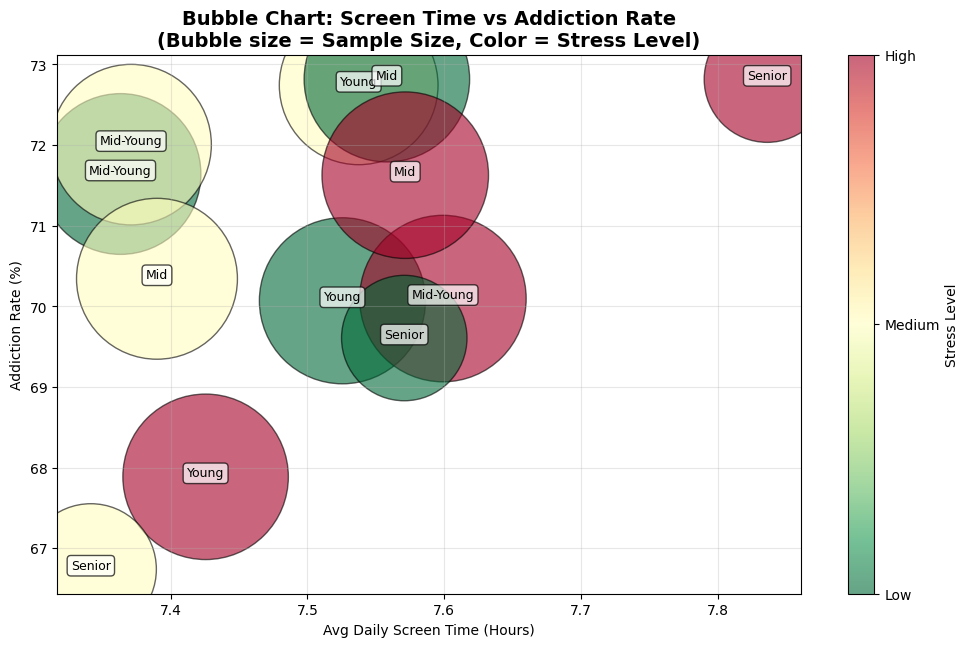

BUBBLE CHART DATA SUMMARY
    age_group stress_level_display  daily_screen_time_hours  addicted_label  \
0       Young                  Low                    7.526           0.701   
1       Young               Medium                    7.537           0.727   
2       Young                 High                    7.426           0.679   
3   Mid-Young                  Low                    7.363           0.716   
4   Mid-Young               Medium                    7.371           0.720   
5   Mid-Young                 High                    7.599           0.701   
6         Mid                  Low                    7.558           0.728   
7         Mid               Medium                    7.390           0.703   
8         Mid                 High                    7.572           0.716   
9      Senior                  Low                    7.571           0.696   
10     Senior               Medium                    7.342           0.667   
11     Senior             

In [12]:

plt.figure(figsize=(12, 7))

# First, check if stress_level is numeric, if not, encode it
if df['stress_level'].dtype == 'object':
    # Create a mapping for stress levels
    stress_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
    df['stress_level_numeric'] = df['stress_level'].map(stress_mapping)
    stress_col = 'stress_level_numeric'
else:
    stress_col = 'stress_level'

# Create aggregated data
bubble_data = df.groupby(['age_group', stress_col]).agg({
    'daily_screen_time_hours': 'mean',
    'addicted_label': 'mean',
    'age': 'count'
}).rename(columns={'age': 'count'}).reset_index()

# Rename stress level column for display
if stress_col == 'stress_level_numeric':
    bubble_data['stress_level_display'] = bubble_data[stress_col].map({0: 'Low', 1: 'Medium', 2: 'High'})
else:
    bubble_data['stress_level_display'] = bubble_data[stress_col]

# Create bubble chart
scatter = plt.scatter(bubble_data['daily_screen_time_hours'], 
                      bubble_data['addicted_label'] * 100,
                      s=bubble_data['count'] * 20,
                      c=bubble_data[stress_col],
                      cmap='RdYlGn_r',
                      alpha=0.6,
                      edgecolors='black',
                      linewidth=1,
                      vmin=0, vmax=2)

plt.xlabel('Avg Daily Screen Time (Hours)')
plt.ylabel('Addiction Rate (%)')
plt.title('Bubble Chart: Screen Time vs Addiction Rate\n(Bubble size = Sample Size, Color = Stress Level)', 
          fontsize=14, fontweight='bold')

# Create custom colorbar with labels
cbar = plt.colorbar(scatter, label='Stress Level')
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(['Low', 'Medium', 'High'])

# Add age group labels
for idx, row in bubble_data.iterrows():
    plt.annotate(row['age_group'], 
                (row['daily_screen_time_hours'], row['addicted_label'] * 100),
                fontsize=9, ha='center', 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

plt.grid(True, alpha=0.3)
plt.show()



print("BUBBLE CHART DATA SUMMARY")

print(bubble_data[['age_group', 'stress_level_display', 'daily_screen_time_hours', 
                   'addicted_label', 'count']].round(3))

## HORIZONTAL BOXEN PLOT - Feature Distribution Comparison

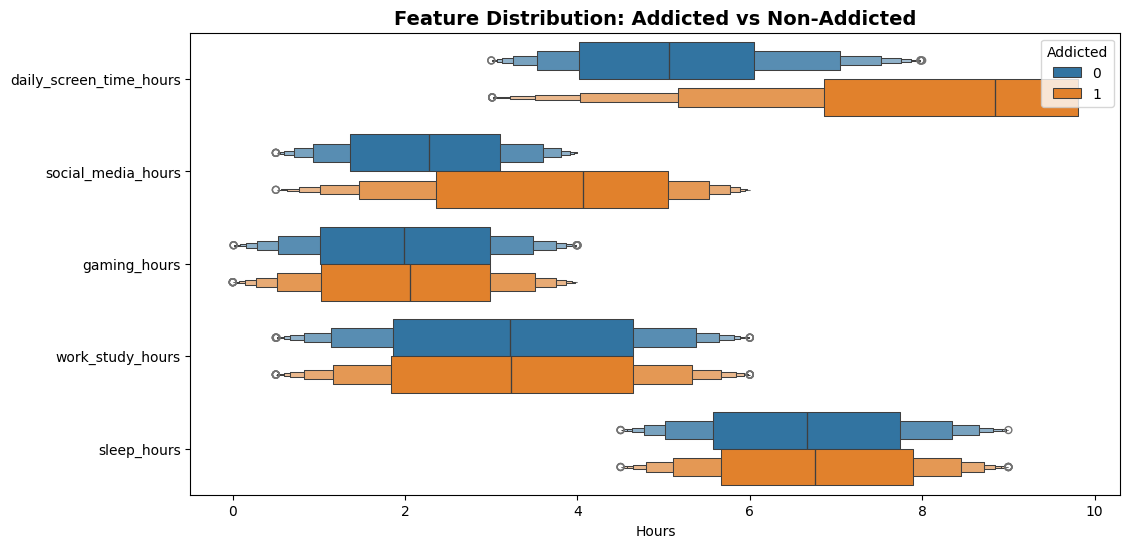

In [13]:

plt.figure(figsize=(12, 6))

# Prepare data for boxen plot
melted_df = pd.melt(df, id_vars=['addicted_label'], 
                    value_vars=['daily_screen_time_hours', 'social_media_hours', 
                               'gaming_hours', 'work_study_hours', 'sleep_hours'])
melted_df['value'] = melted_df['value'].clip(upper=melted_df['value'].quantile(0.95))

sns.boxenplot(x='value', y='variable', hue='addicted_label', data=melted_df)
plt.title('Feature Distribution: Addicted vs Non-Addicted', fontsize=14, fontweight='bold')
plt.xlabel('Hours')
plt.ylabel('')
plt.legend(title='Addicted')
plt.show()

## JOINT PLOT WITH REGRESSION - Screen Time vs Sleep

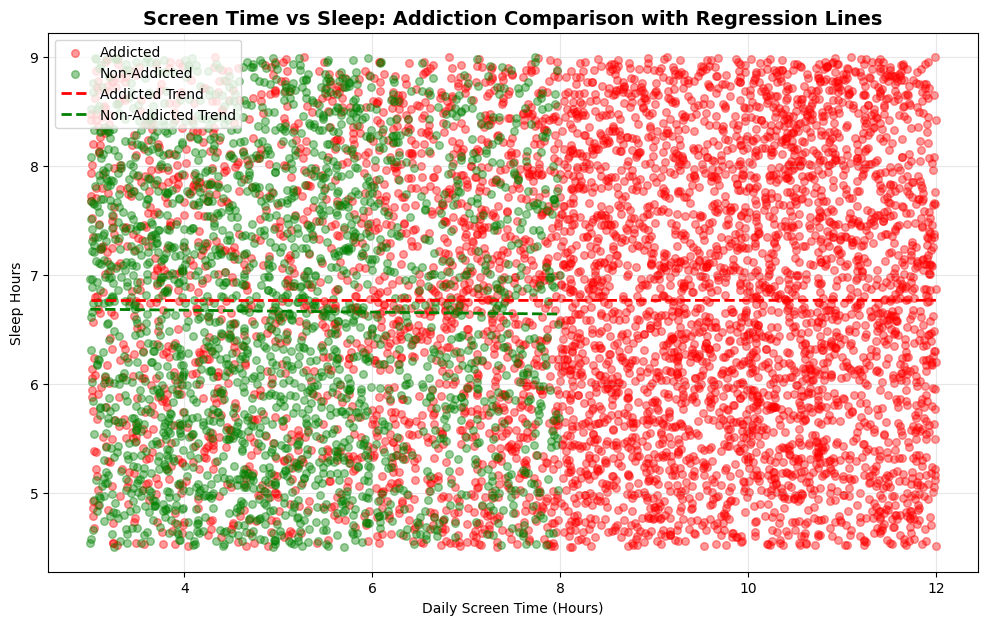

In [14]:

plt.figure(figsize=(12, 7))

# Create separate scatter for addicted groups
addicted = df[df['addicted_label'] == 1]
non_addicted = df[df['addicted_label'] == 0]

plt.scatter(addicted['daily_screen_time_hours'], addicted['sleep_hours'], 
            alpha=0.4, c='red', label='Addicted', s=30)
plt.scatter(non_addicted['daily_screen_time_hours'], non_addicted['sleep_hours'], 
            alpha=0.4, c='green', label='Non-Addicted', s=30)

# Add regression lines
if len(addicted) > 1:
    z_addicted = np.polyfit(addicted['daily_screen_time_hours'], addicted['sleep_hours'], 1)
    p_addicted = np.poly1d(z_addicted)
    plt.plot(sorted(addicted['daily_screen_time_hours']), 
             p_addicted(sorted(addicted['daily_screen_time_hours'])), 
             'r--', linewidth=2, label='Addicted Trend')

if len(non_addicted) > 1:
    z_non = np.polyfit(non_addicted['daily_screen_time_hours'], non_addicted['sleep_hours'], 1)
    p_non = np.poly1d(z_non)
    plt.plot(sorted(non_addicted['daily_screen_time_hours']), 
             p_non(sorted(non_addicted['daily_screen_time_hours'])), 
             'g--', linewidth=2, label='Non-Addicted Trend')

plt.xlabel('Daily Screen Time (Hours)')
plt.ylabel('Sleep Hours')
plt.title('Screen Time vs Sleep: Addiction Comparison with Regression Lines', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## RIDGE PLOT - Distribution Changes Across Age Groups

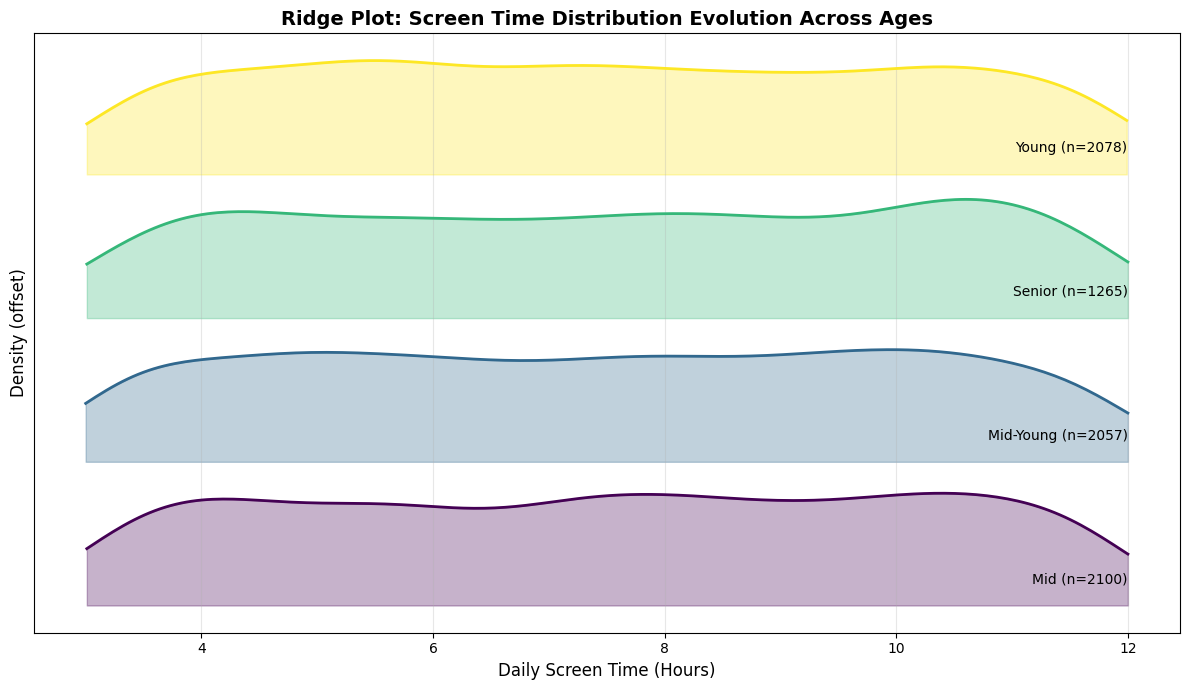

In [15]:
# Import gaussian_kde if not already imported
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(12, 7))

# Drop any NaN values in age_group
df_clean = df.dropna(subset=['age_group'])

age_groups = sorted(df_clean['age_group'].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(age_groups)))

for i, age_group in enumerate(age_groups):
    subset = df_clean[df_clean['age_group'] == age_group]
    if len(subset) > 5:  # Need at least 5 points for KDE
        kde = gaussian_kde(subset['daily_screen_time_hours'])
        x_range = np.linspace(subset['daily_screen_time_hours'].min(), 
                              subset['daily_screen_time_hours'].max(), 200)
        density = kde(x_range)
        # Offset each distribution
        y_offset = i * 0.15
        ax.plot(x_range, density + y_offset, color=colors[i], linewidth=2)
        ax.fill_between(x_range, density + y_offset, y_offset, alpha=0.3, color=colors[i])
        # Add label at the right side
        ax.text(x_range[-1], y_offset + 0.02, f'{age_group} (n={len(subset)})', 
                fontsize=10, ha='right', va='bottom')

ax.set_yticks([])
ax.set_xlabel('Daily Screen Time (Hours)', fontsize=12)
ax.set_ylabel('Density (offset)', fontsize=12)
ax.set_title('Ridge Plot: Screen Time Distribution Evolution Across Ages', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## DIVERGING BAR CHART - Feature Importance for Addiction

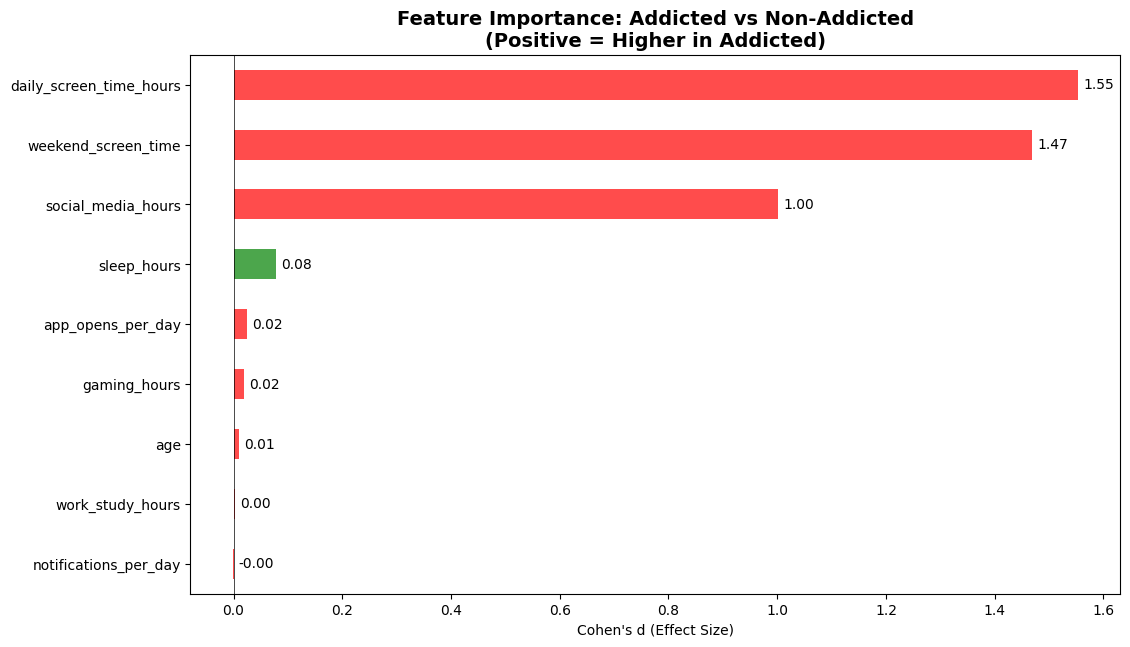

In [16]:

plt.figure(figsize=(12, 7))

features_to_test = ['daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
                   'work_study_hours', 'sleep_hours', 'notifications_per_day',
                   'app_opens_per_day', 'weekend_screen_time', 'age']

cohens_d = []
for feature in features_to_test:
    group1 = df[df['addicted_label'] == 1][feature]
    group2 = df[df['addicted_label'] == 0][feature]
    
    # Cohen's d calculation
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_var = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
    d = (group1.mean() - group2.mean()) / np.sqrt(pooled_var)
    cohens_d.append(d)

# Create diverging bar chart
cohens_d_series = pd.Series(cohens_d, index=features_to_test)
colors_div = ['red' if x > 0 else 'green' for x in cohens_d_series]
cohens_d_series.sort_values().plot(kind='barh', color=colors_div, alpha=0.7)
plt.xlabel("Cohen's d (Effect Size)")
plt.title("Feature Importance: Addicted vs Non-Addicted\n(Positive = Higher in Addicted)", 
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Add value labels
for i, v in enumerate(cohens_d_series.sort_values()):
    plt.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=10)
plt.show()

##  HEXBIN PLOT - App Opens vs Screen Time Density

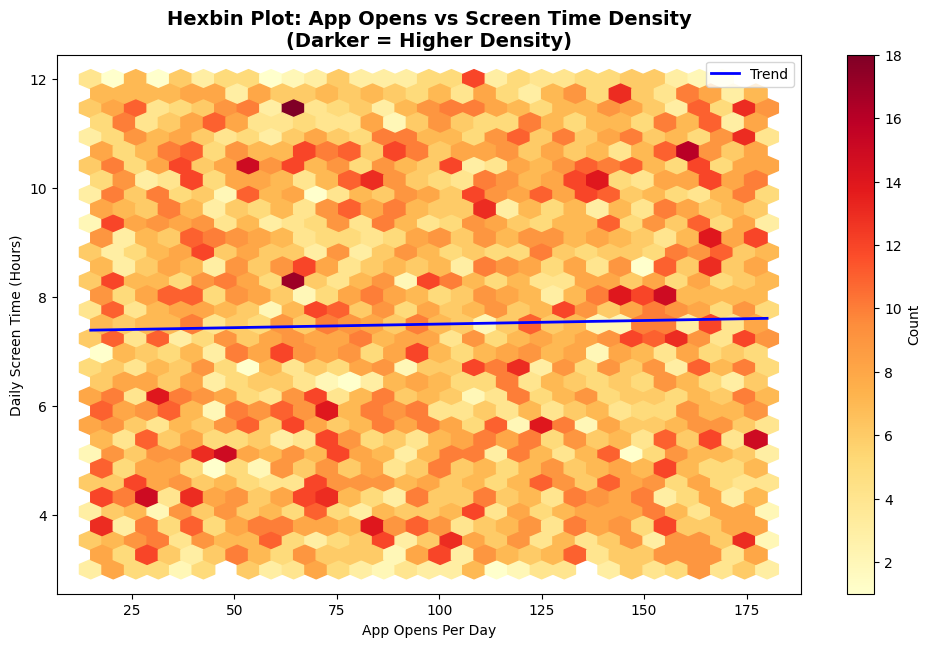

In [17]:

plt.figure(figsize=(12, 7))

hb = plt.hexbin(df['app_opens_per_day'], df['daily_screen_time_hours'], 
                gridsize=30, cmap='YlOrRd', mincnt=1)
plt.xlabel('App Opens Per Day')
plt.ylabel('Daily Screen Time (Hours)')
plt.title('Hexbin Plot: App Opens vs Screen Time Density\n(Darker = Higher Density)', 
          fontsize=14, fontweight='bold')
plt.colorbar(hb, label='Count')

# Add trend line
z = np.polyfit(df['app_opens_per_day'], df['daily_screen_time_hours'], 1)
p = np.poly1d(z)
plt.plot(sorted(df['app_opens_per_day']), 
         p(sorted(df['app_opens_per_day'])), 
         'b-', linewidth=2, label='Trend')
plt.legend()
plt.show()

##   PAIRPLOT - Feature Relationships by Addiction Status

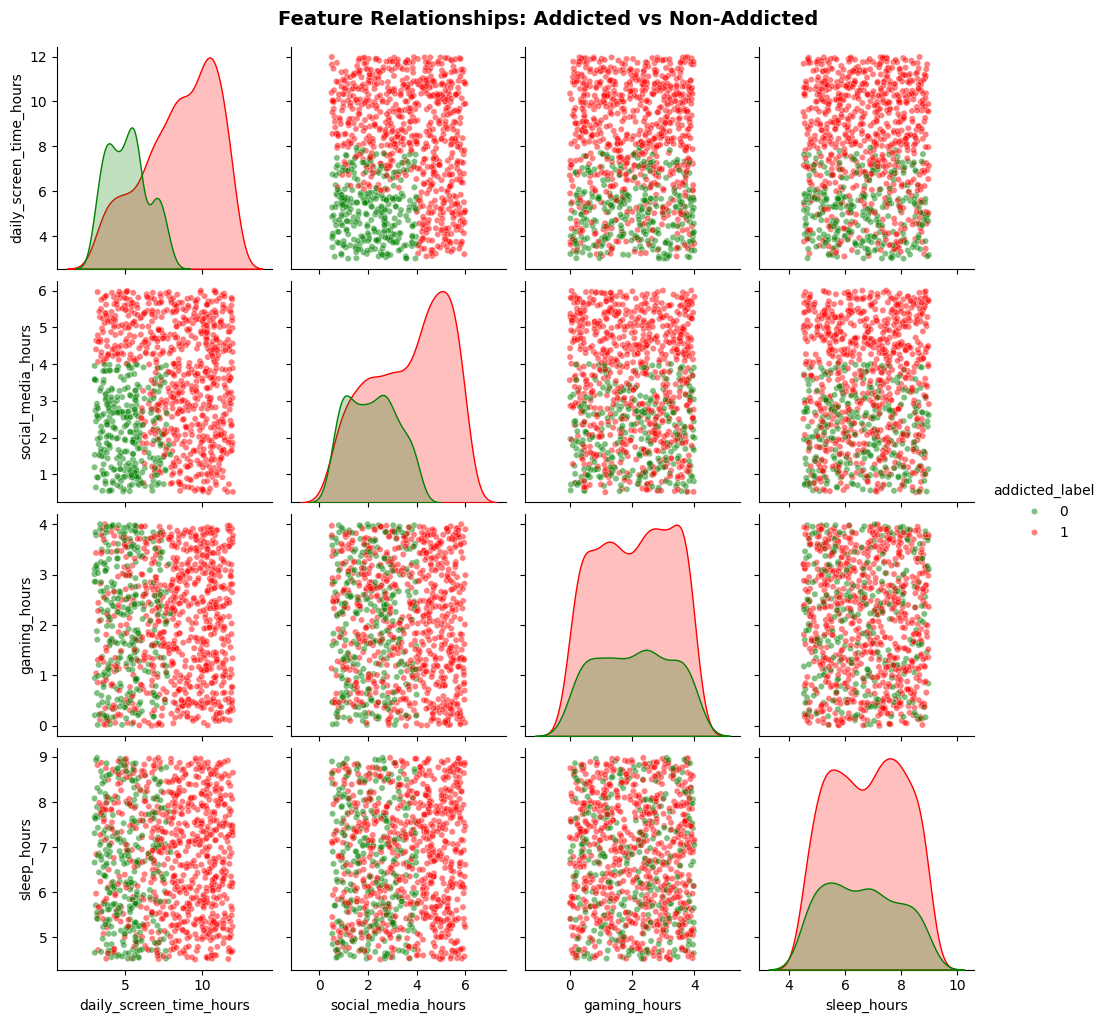

In [18]:

pair_features = ['daily_screen_time_hours', 'social_media_hours', 
                'gaming_hours', 'sleep_hours', 'addicted_label']
df_sample_pair = df[pair_features].sample(min(1000, len(df)))

sns.pairplot(df_sample_pair, hue='addicted_label', palette={0: 'green', 1: 'red'},
             diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})
plt.suptitle('Feature Relationships: Addicted vs Non-Addicted', y=1.02, fontsize=14, fontweight='bold')
plt.show()

##  STATISTICAL COMPARISON: Addicted vs Non-Addicted Groups

In [19]:

import pandas as pd
import numpy as np
from scipy import stats

# Calculate statistics
features_to_test = ['daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
                   'work_study_hours', 'sleep_hours', 'notifications_per_day',
                   'app_opens_per_day', 'weekend_screen_time', 'age']

comparison_stats = []

for feature in features_to_test:
    group1 = df[df['addicted_label'] == 1][feature]
    group2 = df[df['addicted_label'] == 0][feature]
    
    # Calculate means
    addicted_mean = group1.mean()
    non_mean = group2.mean()
    diff_percent = ((addicted_mean - non_mean) / non_mean) * 100
    
    # T-test
    t_stat, p_value = stats.ttest_ind(group1, group2)
    
    # Cohen's d
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_var = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
    cohens_d = (addicted_mean - non_mean) / np.sqrt(pooled_var)
    
    comparison_stats.append({
        'Feature': feature,
        'Addicted Mean': f'{addicted_mean:.2f}',
        'Non-Addicted Mean': f'{non_mean:.2f}',
        'Difference %': f'{diff_percent:+.1f}%',
        'P-value': f'{p_value:.4f}',
        'Significant': '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns',
        'Cohen\'s d': f'{cohens_d:.2f}',
        'Effect Size': 'Large' if abs(cohens_d) > 0.8 else 'Medium' if abs(cohens_d) > 0.5 else 'Small' if abs(cohens_d) > 0.2 else 'Negligible'
    })

# Create DataFrame
comparison_df = pd.DataFrame(comparison_stats)


print("STATISTICAL COMPARISON: Addicted vs Non-Addicted Groups")

print(comparison_df.to_string(index=False))

# Create styled version
# Convert numeric columns for styling
comparison_df['Diff % Num'] = comparison_df['Difference %'].str.replace('%','').astype(float)
comparison_df['P-value Num'] = comparison_df['P-value'].astype(float)
comparison_df['Cohen\'s d Num'] = comparison_df['Cohen\'s d'].astype(float)

# Apply styling
styled = comparison_df.style \
    .background_gradient(subset=['Diff % Num'], cmap='RdYlGn', vmin=-50, vmax=50) \
    .background_gradient(subset=['P-value Num'], cmap='coolwarm_r', vmin=0, vmax=0.1) \
    .background_gradient(subset=["Cohen's d Num"], cmap='Blues', vmin=0, vmax=1.5) \
    .set_properties(**{'text-align': 'center'}) \
    .set_caption(" Statistical Comparison: Addicted vs Non-Addicted Smartphone Users") \
    .format({
        'P-value Num': "{:.4f}",
        'Diff % Num': "{:+.1f}%",
        "Cohen's d Num": "{:.2f}"
    }) \
    .hide(['Diff % Num', 'P-value Num', "Cohen's d Num"], axis=1) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('padding', '8px')]}
    ])

# Display styled table
from IPython.display import display
display(styled)

# Additional insights

print("KEY STATISTICAL INSIGHTS")


# Most significant features
most_significant = comparison_df[comparison_df['Significant'] == '***'].sort_values("Cohen's d Num", ascending=False)
print("\n STRONGEST EFFECTS (Cohen's d > 0.8):")
for idx, row in most_significant[most_significant["Cohen's d Num"] > 0.8].iterrows():
    print(f"  • {row['Feature']}: {row['Cohen\'s d']} ({row['Effect Size']}) - {row['Difference %']} difference")

# Features with no significant difference
not_significant = comparison_df[comparison_df['Significant'] == 'ns']
if len(not_significant) > 0:
    print("\n NO SIGNIFICANT DIFFERENCE:")
    for idx, row in not_significant.iterrows():
        print(f"  • {row['Feature']}: p={row['P-value']}")

# Summary statistics
print("\n SUMMARY:")
print(f"   Total features compared: {len(comparison_df)}")
print(f"   Features with p < 0.001 (***): {len(comparison_df[comparison_df['Significant'] == '***'])}")
print(f"   Features with p < 0.01 (**): {len(comparison_df[comparison_df['Significant'] == '**'])}")
print(f"   Features with p < 0.05 (*): {len(comparison_df[comparison_df['Significant'] == '*'])}")
print(f"   Non-significant features: {len(comparison_df[comparison_df['Significant'] == 'ns'])}")

# Top 3 features differentiating addicted vs non-addicted
print("\n TOP 3 DIFFERENTIATING FEATURES (by Cohen's d):")
top_features = comparison_df.nlargest(3, "Cohen's d Num")
for idx, row in top_features.iterrows():
    print(f"  {idx+1}. {row['Feature']}: {row['Cohen\'s d']} (Cohen's d) - {row['Difference %']} higher in addicted")

STATISTICAL COMPARISON: Addicted vs Non-Addicted Groups
                Feature Addicted Mean Non-Addicted Mean Difference % P-value Significant Cohen's d Effect Size
daily_screen_time_hours          8.47              5.16       +64.2%  0.0000         ***      1.55       Large
     social_media_hours          3.70              2.25       +64.1%  0.0000         ***      1.00       Large
           gaming_hours          2.02              2.00        +1.1%  0.4625          ns      0.02  Negligible
       work_study_hours          3.24              3.24        +0.1%  0.9239          ns      0.00  Negligible
            sleep_hours          6.77              6.67        +1.5%  0.0021          **      0.08  Negligible
  notifications_per_day        134.23            134.33        -0.1%  0.9544          ns     -0.00  Negligible
      app_opens_per_day         98.18             97.00        +1.2%  0.3390          ns      0.02  Negligible
    weekend_screen_time         10.21              6.89 

,Feature,Addicted Mean,Non-Addicted Mean,Difference %,P-value,Significant,Cohen's d,Effect Size
0,daily_screen_time_hours,8.47,5.16,+64.2%,0.0000,***,1.55,Large
1,social_media_hours,3.70,2.25,+64.1%,0.0000,***,1.00,Large
2,gaming_hours,2.02,2.00,+1.1%,0.4625,ns,0.02,Negligible
3,work_study_hours,3.24,3.24,+0.1%,0.9239,ns,0.00,Negligible
4,sleep_hours,6.77,6.67,+1.5%,0.0021,**,0.08,Negligible
5,notifications_per_day,134.23,134.33,-0.1%,0.9544,ns,-0.00,Negligible
6,app_opens_per_day,98.18,97.00,+1.2%,0.3390,ns,0.02,Negligible
7,weekend_screen_time,10.21,6.89,+48.1%,0.0000,***,1.47,Large
8,age,26.58,26.53,+0.2%,0.7148,ns,0.01,Negligible


KEY STATISTICAL INSIGHTS

 STRONGEST EFFECTS (Cohen's d > 0.8):
  • daily_screen_time_hours: 1.55 (Large) - +64.2% difference
  • weekend_screen_time: 1.47 (Large) - +48.1% difference
  • social_media_hours: 1.00 (Large) - +64.1% difference

 NO SIGNIFICANT DIFFERENCE:
  • gaming_hours: p=0.4625
  • work_study_hours: p=0.9239
  • notifications_per_day: p=0.9544
  • app_opens_per_day: p=0.3390
  • age: p=0.7148

 SUMMARY:
   Total features compared: 9
   Features with p < 0.001 (***): 3
   Features with p < 0.01 (**): 1
   Features with p < 0.05 (*): 0
   Non-significant features: 5

 TOP 3 DIFFERENTIATING FEATURES (by Cohen's d):
  1. daily_screen_time_hours: 1.55 (Cohen's d) - +64.2% higher in addicted
  8. weekend_screen_time: 1.47 (Cohen's d) - +48.1% higher in addicted
  2. social_media_hours: 1.00 (Cohen's d) - +64.1% higher in addicted


#  Prepare Data

In [20]:

X = df.drop(columns=['addicted_label'])
y = df['addicted_label']





# Check categorical columns

# Detect BOTH object + category
cat_cols = X.select_dtypes(include=['object', 'category']).columns
print("Categorical columns:", cat_cols)

# One-hot encode 
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# SMOTE 

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)


#  TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res,
    test_size=0.2,
    random_state=42,
    stratify=y_res
)


# SCALING

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Categorical columns: Index(['transaction_id', 'user_id', 'gender', 'stress_level',
       'academic_work_impact', 'addiction_level', 'age_group'],
      dtype='object')


#   Models

In [21]:


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6, use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42,verbosity=-1 )
}

#  Train, Predict & Compare Models


Logistic Regression Accuracy: 0.9826
Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      1062
           1       1.00      0.97      0.98      1062

    accuracy                           0.98      2124
   macro avg       0.98      0.98      0.98      2124
weighted avg       0.98      0.98      0.98      2124



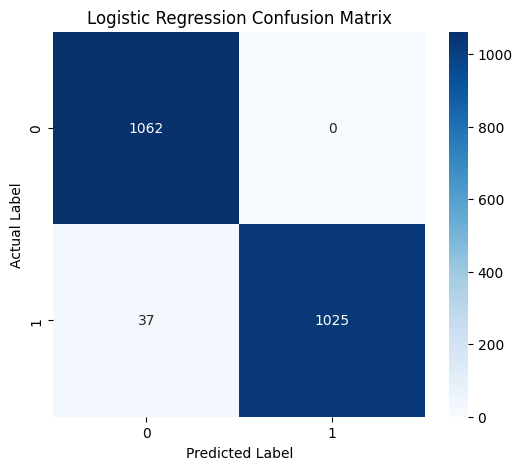


Random Forest Accuracy: 0.9840
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      1062
           1       1.00      0.97      0.98      1062

    accuracy                           0.98      2124
   macro avg       0.98      0.98      0.98      2124
weighted avg       0.98      0.98      0.98      2124



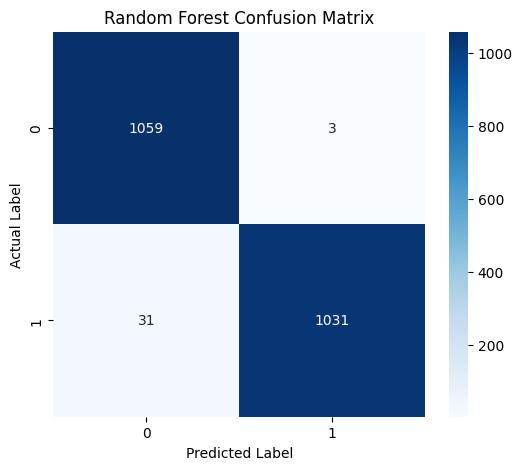


Gradient Boosting Accuracy: 0.9991
Gradient Boosting Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1062
           1       1.00      1.00      1.00      1062

    accuracy                           1.00      2124
   macro avg       1.00      1.00      1.00      2124
weighted avg       1.00      1.00      1.00      2124



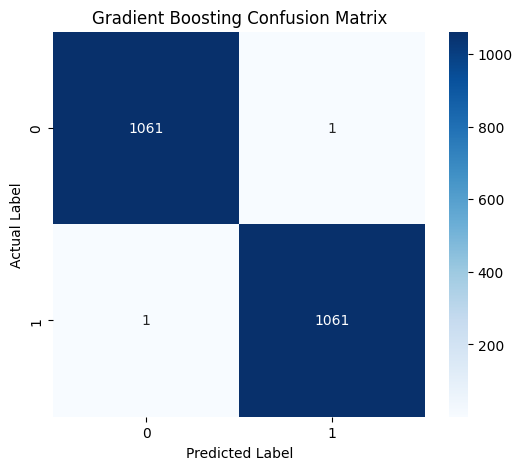

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:28:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Accuracy: 0.9995
XGBoost Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1062
           1       1.00      1.00      1.00      1062

    accuracy                           1.00      2124
   macro avg       1.00      1.00      1.00      2124
weighted avg       1.00      1.00      1.00      2124



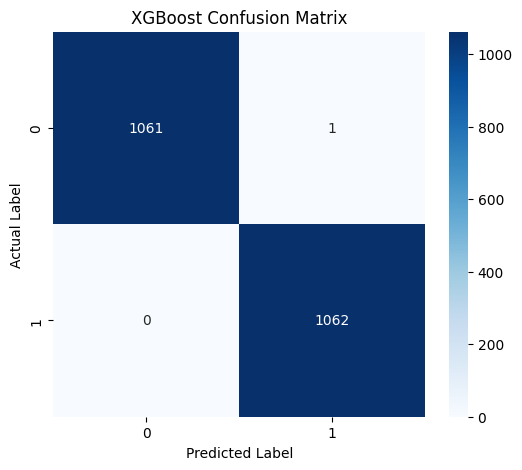


LightGBM Accuracy: 1.0000
LightGBM Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1062
           1       1.00      1.00      1.00      1062

    accuracy                           1.00      2124
   macro avg       1.00      1.00      1.00      2124
weighted avg       1.00      1.00      1.00      2124



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


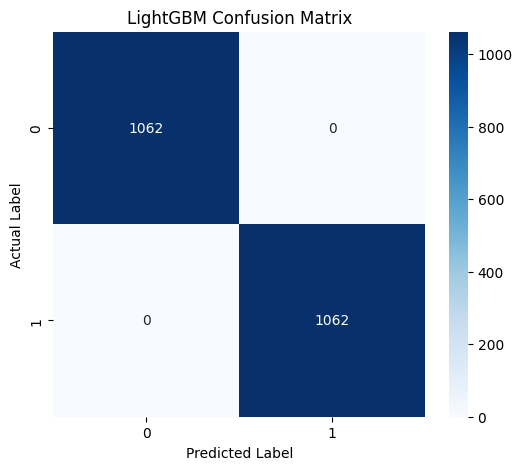

In [22]:

accuracy_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_results[name] = acc
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(f"{name} Classification Report:\n", classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.show()


#  Compare Model Accuracies

/tmp/ipykernel_600/2659844475.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=acc_df, palette='viridis')


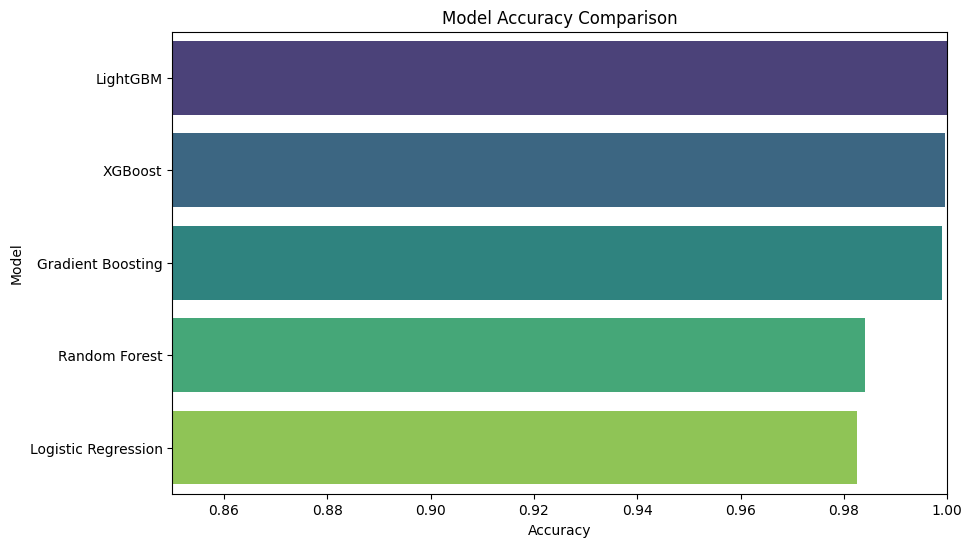

In [23]:

acc_df = pd.DataFrame(list(accuracy_results.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x='Accuracy', y='Model', data=acc_df, palette='viridis')
plt.title("Model Accuracy Comparison")
plt.xlim(0.85,1.0)
plt.show()

#  Feature Importance for Best Model 

In [24]:
best_model_name = acc_df.iloc[0]['Model']
print(f"Best Model: {best_model_name}")

best_model = models[best_model_name]




Best Model: LightGBM


# Overall Summary

**What we mainly do:**

We analyze the dataset using data preprocessing, exploratory data analysis (EDA), visualization, and multiple machine learning models to understand patterns and make predictions.

**Why we do it:**

Traditional analysis cannot easily capture complex relationships in data. AI and machine learning help find hidden patterns, trends, and important features that influence the outcome.

**What we can achieve:**

- Build accurate prediction models

- Compare different algorithms to find the best one

- Generate useful insights from the data

- Support better data-driven decisions and future improvements.